1. Project Introduction
2. Import Libraries
3. Define Data Parameters
4. Download Gold Price Data
5. Initial Inspection
6. Save Raw Data


# Gold Volatility Analysis

## Objective

This project analyzes the historical price behavior and volatility of gold.

The main objectives are:

- Analyze historical gold prices
- Calculate daily and log returns
- Measure historical and rolling volatility
- Investigate volatility clustering
- Model volatility using GARCH
- Evaluate market risk using VaR and Expected Shortfall

The analysis is designed as a financial analytics and quantitative research project.

## Phase 1 — Data Collection

In this phase, historical gold price data is collected and stored as raw data.

No financial transformations are performed at this stage.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import yfinance as yf

In [2]:
BASE_DIR = Path.cwd().parent

RAW_DIR = BASE_DIR / "Data" / "raw"
PROCESSED_DIR = BASE_DIR / "Data" / "processed"

RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print("Raw data path:", RAW_DIR)
print("Processed data path:", PROCESSED_DIR)

Raw data path: c:\Users\r\Documents\GitHub\Gold-Volatility-Analysis\Data\raw
Processed data path: c:\Users\r\Documents\GitHub\Gold-Volatility-Analysis\Data\processed


## Download Gold Futures Data

Gold futures historical data is collected from Yahoo Finance using
the ticker symbol `GC=F`.

The dataset contains daily OHLC prices, adjusted closing price,
and trading volume.

In [4]:
ticker = "GC=F"

gold_df = yf.download(
    ticker,
    start="2010-01-01",
    progress=False,
    auto_adjust=False
)

gold_df.head()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,GC=F,GC=F,GC=F,GC=F,GC=F,GC=F
Date,,,,,,
2010-01-04,1117.699951,1117.699951,1122.300049,1097.099976,1117.699951,184
2010-01-05,1118.099976,1118.099976,1126.500000,1115.000000,1118.099976,53
2010-01-06,1135.900024,1135.900024,1139.199951,1120.699951,1135.900024,363
2010-01-07,1133.099976,1133.099976,1133.099976,1129.199951,1133.099976,56
2010-01-08,1138.199951,1138.199951,1138.199951,1122.699951,1138.199951,54


In [5]:
print("Shape:", gold_df.shape)
print("\nColumns:")
print(gold_df.columns)

print("\nMissing Values:")
print(gold_df.isnull().sum())

gold_df.info()

Shape: (4207, 6)

Columns:
MultiIndex([('Adj Close', 'GC=F'),
            (    'Close', 'GC=F'),
            (     'High', 'GC=F'),
            (      'Low', 'GC=F'),
            (     'Open', 'GC=F'),
            (   'Volume', 'GC=F')],
           names=['Price', 'Ticker'])

Missing Values:
Price      Ticker
Adj Close  GC=F      0
Close      GC=F      0
High       GC=F      0
Low        GC=F      0
Open       GC=F      0
Volume     GC=F      0
dtype: int64
<class 'pandas.DataFrame'>
DatetimeIndex: 4207 entries, 2010-01-04 to 2026-09-24
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Adj Close, GC=F)  4207 non-null   float64
 1   (Close, GC=F)      4207 non-null   float64
 2   (High, GC=F)       4207 non-null   float64
 3   (Low, GC=F)        4207 non-null   float64
 4   (Open, GC=F)       4207 non-null   float64
 5   (Volume, GC=F)     4207 non-null   int64  
dtypes: float64(5), int64(1)
memory usage

In [6]:
display(gold_df.head())

display(gold_df.tail())

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,GC=F,GC=F,GC=F,GC=F,GC=F,GC=F
Date,,,,,,
2010-01-04,1117.699951,1117.699951,1122.300049,1097.099976,1117.699951,184
2010-01-05,1118.099976,1118.099976,1126.500000,1115.000000,1118.099976,53
2010-01-06,1135.900024,1135.900024,1139.199951,1120.699951,1135.900024,363
2010-01-07,1133.099976,1133.099976,1133.099976,1129.199951,1133.099976,56
2010-01-08,1138.199951,1138.199951,1138.199951,1122.699951,1138.199951,54


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,GC=F,GC=F,GC=F,GC=F,GC=F,GC=F
Date,,,,,,
2026-09-18,4424.899902,4424.899902,4439.799805,4372.200195,4381.600098,142919
2026-09-21,4383.899902,4383.899902,4422.100098,4360.299805,4413.000000,138203
2026-09-22,4376.399902,4376.399902,4414.100098,4327.600098,4382.500000,178132
2026-09-23,4318.399902,4318.399902,4407.500000,4310.700195,4394.700195,178132
2026-09-24,4307.399902,4307.399902,4338.000000,4278.299805,4324.399902,158403


In [7]:
output_file = RAW_DIR / "gold_price.csv"

gold_df.to_csv(output_file)

print(f"File saved successfully:\n{output_file}")

File saved successfully:
c:\Users\r\Documents\GitHub\Gold-Volatility-Analysis\Data\raw\gold_price.csv


## Phase 1 Summary

Historical gold futures data was successfully collected from Yahoo Finance
using the ticker symbol `GC=F`.

The raw dataset has been stored without any transformations and will be
used in subsequent phases for cleaning, return calculation, volatility
analysis, and risk modeling.

In [8]:
gold_df.shape

gold_df.head()

gold_df.tail()

gold_df.isnull().sum()

Price      Ticker
Adj Close  GC=F      0
Close      GC=F      0
High       GC=F      0
Low        GC=F      0
Open       GC=F      0
Volume     GC=F      0
dtype: int64

# Phase 2 — Data Cleaning & Exploratory Data Analysis

In this phase, the raw gold futures dataset is cleaned and prepared
for financial time-series analysis.

The main objectives are:

- Inspect the raw dataset
- Simplify the dataset structure
- Prepare the date index
- Select the relevant price variable
- Check data quality
- Explore the historical price behavior
- Create a processed dataset for subsequent return and volatility analysis

In [14]:
raw_file = RAW_DIR / "gold_price.csv"

gold_raw = pd.read_csv(
    raw_file,
    header=[0, 1],
    index_col=0,
    parse_dates=True
)

gold_raw.head()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,GC=F,GC=F,GC=F,GC=F,GC=F,GC=F
Date,,,,,,
2010-01-04,1117.699951,1117.699951,1122.300049,1097.099976,1117.699951,184
2010-01-05,1118.099976,1118.099976,1126.500000,1115.000000,1118.099976,53
2010-01-06,1135.900024,1135.900024,1139.199951,1120.699951,1135.900024,363
2010-01-07,1133.099976,1133.099976,1133.099976,1129.199951,1133.099976,56
2010-01-08,1138.199951,1138.199951,1138.199951,1122.699951,1138.199951,54


In [16]:
gold_raw.columns = gold_raw.columns.get_level_values(0)

gold_raw.head()

Price,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2010-01-04,1117.699951,1117.699951,1122.300049,1097.099976,1117.699951,184
2010-01-05,1118.099976,1118.099976,1126.500000,1115.000000,1118.099976,53
2010-01-06,1135.900024,1135.900024,1139.199951,1120.699951,1135.900024,363
2010-01-07,1133.099976,1133.099976,1133.099976,1129.199951,1133.099976,56
2010-01-08,1138.199951,1138.199951,1138.199951,1122.699951,1138.199951,54


## Select Relevant Variables

For the volatility analysis, the closing price is the primary price variable.

The processed dataset will initially retain:

- Date
- Close
- Open
- High
- Low
- Volume

In [18]:
gold = gold_raw[
    ["Open", "High", "Low", "Close", "Volume"]
].copy()

gold.head()

Price,Open,High,Low,Close,Volume
Date,,,,,
2010-01-04,1117.699951,1122.300049,1097.099976,1117.699951,184
2010-01-05,1118.099976,1126.500000,1115.000000,1118.099976,53
2010-01-06,1135.900024,1139.199951,1120.699951,1135.900024,363
2010-01-07,1133.099976,1133.099976,1129.199951,1133.099976,56
2010-01-08,1138.199951,1138.199951,1122.699951,1138.199951,54


In [19]:
print("Index type:", type(gold.index))
print("Start date:", gold.index.min())
print("End date:", gold.index.max())

Index type: <class 'pandas.DatetimeIndex'>
Start date: 2010-01-04 00:00:00
End date: 2026-09-24 00:00:00


In [20]:
gold.index.name = "Date"

gold.head()

Price,Open,High,Low,Close,Volume
Date,,,,,
2010-01-04,1117.699951,1122.300049,1097.099976,1117.699951,184
2010-01-05,1118.099976,1126.500000,1115.000000,1118.099976,53
2010-01-06,1135.900024,1139.199951,1120.699951,1135.900024,363
2010-01-07,1133.099976,1133.099976,1129.199951,1133.099976,56
2010-01-08,1138.199951,1138.199951,1122.699951,1138.199951,54


## Data Quality Checks

The processed dataset is checked for:

- Missing values
- Duplicate dates
- Invalid prices
- Incorrect date ordering

In [21]:
gold.isnull().sum()

Price
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

In [22]:
print("Duplicate dates:", gold.index.duplicated().sum())

Duplicate dates: 0


In [23]:
price_columns = ["Open", "High", "Low", "Close"]

(gold[price_columns] <= 0).sum()

Price
Open     0
High     0
Low      0
Close    0
dtype: int64

In [24]:
print("Sorted by date:", gold.index.is_monotonic_increasing)

Sorted by date: True


In [25]:
gold.describe()

Price,Open,High,Low,Close,Volume
count,4207.000000,4207.000000,4207.000000,4207.000000,4207.000000
mean,1793.991871,1806.808248,1780.538032,1794.052721,77954.278108
std,830.510497,843.174059,817.495379,830.905124,105577.715435
min,1052.199951,1062.000000,1045.199951,1050.800049,0.000000
25%,1274.149963,1279.299988,1269.299988,1273.599976,79.000000
50%,1559.300049,1569.099976,1549.800049,1560.599976,598.000000
75%,1879.649963,1896.250000,1866.399963,1879.549988,167867.000000
max,5415.700195,5586.200195,5272.899902,5318.399902,570055.000000


## Historical Gold Price

The historical closing price is visualized to examine the long-term
price behavior of gold futures.

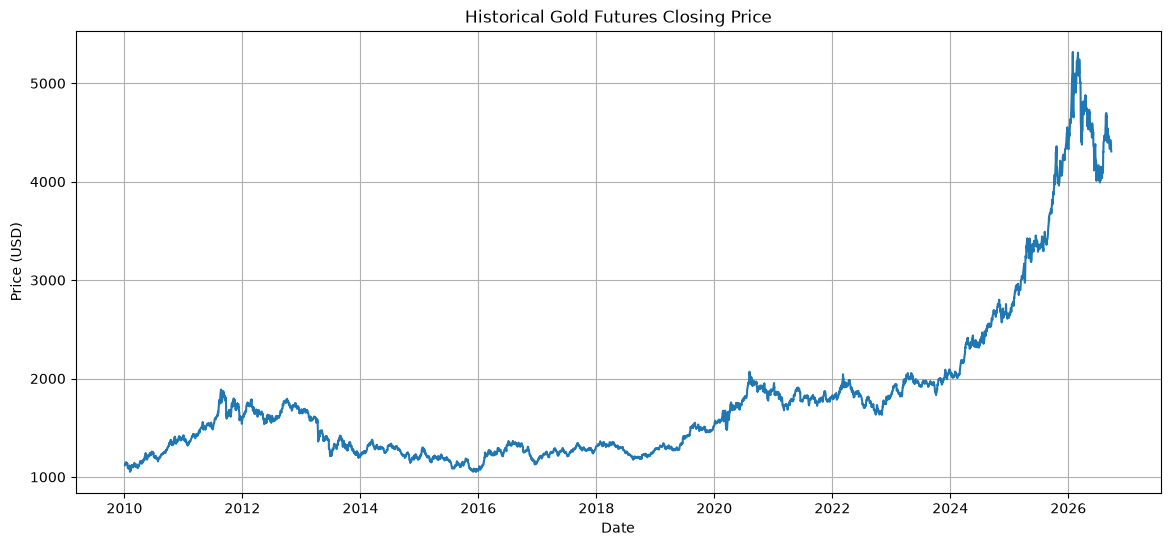

In [26]:
plt.figure(figsize=(14, 6))

plt.plot(gold.index, gold["Close"])

plt.title("Historical Gold Futures Closing Price")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.grid(True)

plt.show()

In [27]:
processed_file = PROCESSED_DIR / "gold_clean.csv"

gold.to_csv(processed_file)

print(f"Processed data saved successfully:\n{processed_file}")

Processed data saved successfully:
c:\Users\r\Documents\GitHub\Gold-Volatility-Analysis\Data\processed\gold_clean.csv


## Phase 2 Summary

The raw gold futures dataset was cleaned and prepared for financial
time-series analysis.

The following steps were completed:

- Simplified the MultiIndex column structure
- Selected relevant OHLCV variables
- Prepared the Date index
- Checked missing values
- Checked duplicate dates
- Validated price values
- Verified chronological ordering
- Generated descriptive statistics
- Visualized the historical closing price
- Saved the processed dataset

The cleaned dataset is now ready for return calculation and volatility analysis.